In [ ]:
#Instalo las librerías necesarias para el análisis de datos y visualización

%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset generado con 1500 registros

=== Resultados del Modelo ===
Mean Absolute Error (MAE)  : 2.57 minutos
Root Mean Squared Error (RMSE): 3.30 minutos
R² Score                   : 0.8575


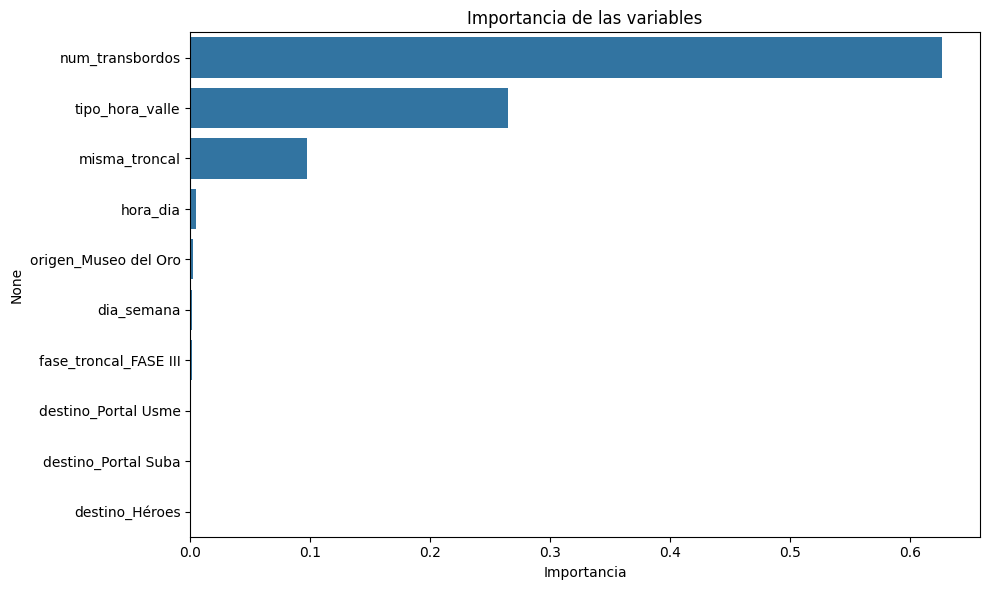

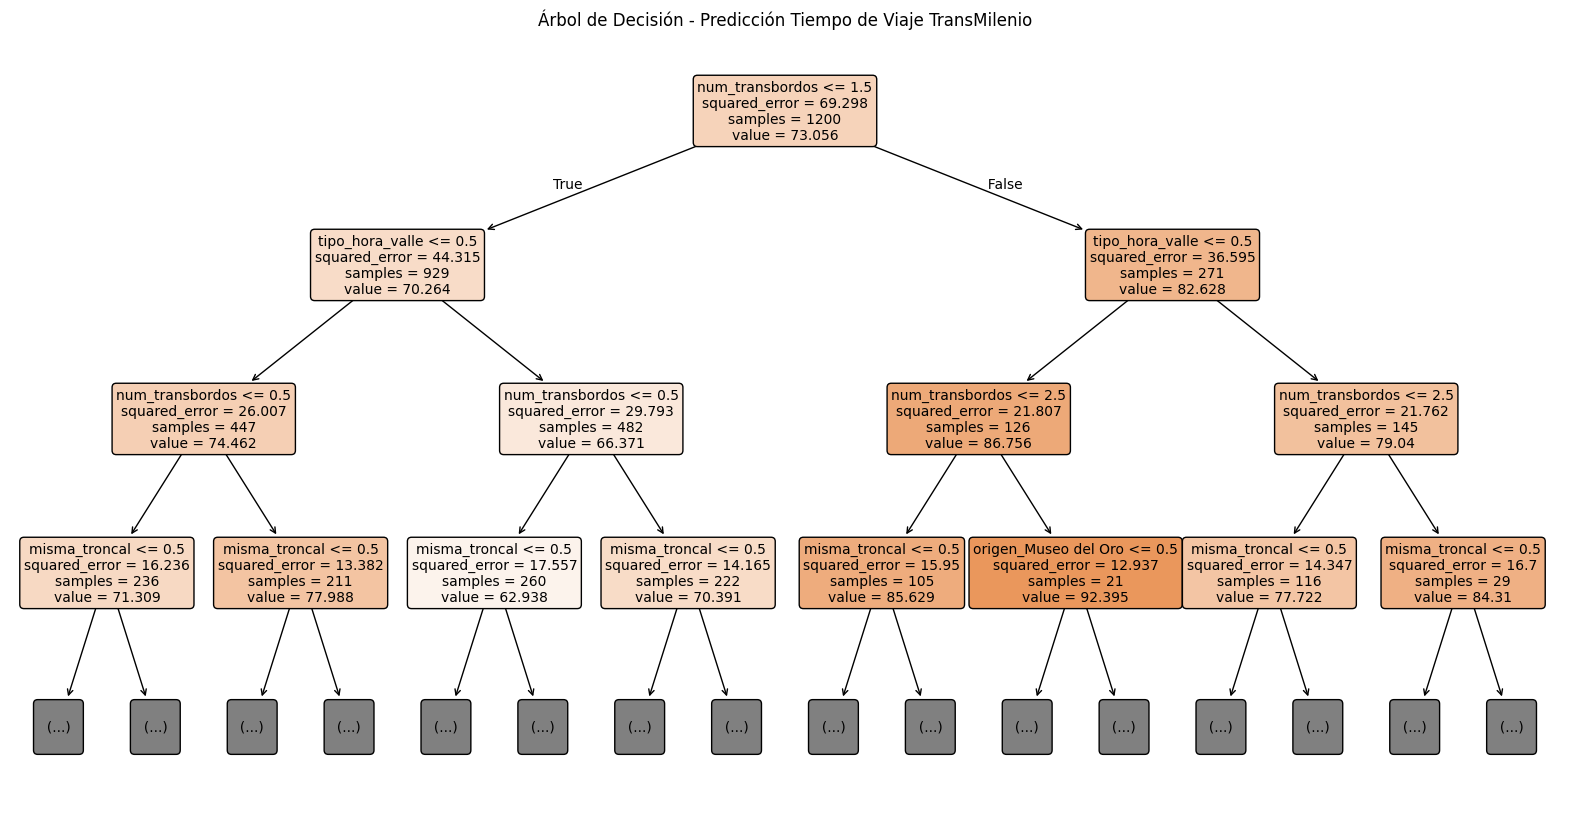


=== Ejemplos de Predicción ===
De Héroes a Terminal (Autopista Norte): Predicción = 67.5 minutos
De Portal Suba a Portal Usme: Predicción = 90.7 minutos
De Portal Tunal a Portal Américas: Predicción = 79.6 minutos


In [3]:
# ====================== IMPORTACIÓN DE LIBRERÍAS ======================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # ← Agregado mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== GENERACIÓN DEL DATASET ======================
np.random.seed(42)

n = 1500
data = {
    'origen': np.random.choice(['Héroes', 'Portal Suba', 'Portal Tunal', 'Museo del Oro', 'AV. Jiménez', 'Terminal (Autopista Norte)', 'Portal Usme', 'Portal Américas'], n),
    'destino': np.random.choice(['Héroes', 'Portal Suba', 'Portal Tunal', 'Museo del Oro', 'AV. Jiménez', 'Terminal (Autopista Norte)', 'Portal Usme', 'Portal Américas'], n),
    'misma_troncal': np.random.choice([0, 1], n, p=[0.65, 0.35]),
    'num_transbordos': np.random.choice([0, 1, 2, 3], n, p=[0.40, 0.35, 0.20, 0.05]),
    'distancia_km': np.round(np.random.uniform(2, 35), 1),
    'hora_dia': np.random.randint(5, 23, n),
    'dia_semana': np.random.randint(0, 7, n),
    'tipo_hora': np.random.choice(['pico', 'valle'], n, p=[0.45, 0.55]),
    'fase_troncal': np.random.choice(['FASE I', 'FASE II', 'FASE III'], n, p=[0.50, 0.35, 0.15])
}

df = pd.DataFrame(data)

df['tiempo_viaje_minutos'] = (
    df['distancia_km'] * 2.8 +
    df['num_transbordos'] * 7 +
    np.where(df['tipo_hora'] == 'pico', 12, 4) +
    np.where(df['misma_troncal'] == 1, -5, 0) +
    np.random.normal(0, 3, n)
)
df['tiempo_viaje_minutos'] = df['tiempo_viaje_minutos'].clip(lower=8).round(1)

df.to_csv('transmilenio_dataset.csv', index=False)
print("Dataset generado con", len(df), "registros")

# ====================== PREPROCESAMIENTO Y MODELO ======================
X = df.drop('tiempo_viaje_minutos', axis=1)
y = df['tiempo_viaje_minutos']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

# ====================== MÉTRICAS (incluyendo RMSE) ======================
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))   # ← Calculado aquí
r2 = r2_score(y_test, predicciones)

print("\n=== Resultados del Modelo ===")
print(f"Mean Absolute Error (MAE)  : {mae:.2f} minutos")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutos")   # ← Nuevo
print(f"R² Score                   : {r2:.4f}")

# ====================== VISUALIZACIÓN ======================
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values[:10], y=importancias.index[:10])
plt.title('Importancia de las variables')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('importancia_variables.png')
plt.show()

# Árbol (primeros niveles)
plt.figure(figsize=(20, 10))
plot_tree(modelo, feature_names=X.columns, filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title('Árbol de Decisión - Predicción Tiempo de Viaje TransMilenio')
plt.savefig('arbol_decision_transmilenio.png')
plt.show()

# Ejemplos de predicción
print("\n=== Ejemplos de Predicción ===")
ejemplos = pd.DataFrame({
    'origen': ['Héroes', 'Portal Suba', 'Portal Tunal'],
    'destino': ['Terminal (Autopista Norte)', 'Portal Usme', 'Portal Américas'],
    'misma_troncal': [1, 0, 0],
    'num_transbordos': [0, 3, 2],
    'distancia_km': [12.5, 28.0, 18.5],
    'hora_dia': [8, 18, 14],
    'dia_semana': [2, 4, 1],
    'tipo_hora': ['pico', 'pico', 'valle'],
    'fase_troncal': ['FASE I', 'FASE II', 'FASE I']
})

ejemplos_encoded = pd.get_dummies(ejemplos, drop_first=True)
ejemplos_encoded = ejemplos_encoded.reindex(columns=X.columns, fill_value=0)

pred_ej = modelo.predict(ejemplos_encoded)
for i, row in ejemplos.iterrows():
    print(f"De {row['origen']} a {row['destino']}: Predicción = {pred_ej[i]:.1f} minutos")